In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

from tqdm import tqdm
from numpy.typing import NDArray
import numpy as np

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

E_MIN, E_MAX = None, None

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_MIN, E_max=E_MAX)
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

In [4]:
#from typing import Callable
#
#from scipy.optimize import differential_evolution
#
#from bloodmoon.coords import pos2shift
#from bloodmoon.optim import model_sky, process_skyimg
#
#
#def MSEloss(
#    func: Callable[[float, float, float], NDArray],
#) -> Callable[[NDArray, *tuple[NDArray, NDArray]], float]:
#    """
#    Returns a loss function for source parameter optimization, given a routine for computing models.
#    """
#    def f(x: NDArray, *args: tuple[NDArray, NDArray]) -> float:
#        """Compute the Mean Square Error loss between source model and true data."""
#        modeled = func(*x)
#        true, sigma = args
#        mse = np.mean(np.square((true - modeled) / sigma))
#        return float(mse)
#    
#    return f
#
#
#def config_optimiser(
#    camera: CodedMaskCamera,
#    vignetting: bool = True,
#    psfy: bool = True,
#    camera_coding_power: float = 0.85,
#) -> Callable[[NDArray, tuple[int, int], bool], tuple[float, float, float]]:
#    """
#    Configures the IROS optimiser for source parameters fitting.
#    """
#    def _ModelShiftFluence(
#        pos: tuple[int, int],
#    ) -> Callable[[float, float, float], NDArray]:
#        """
#        Initialises the source model.
#        """
#        def f(sx: float, sy: float, cts: float) -> NDArray:
#            """Models the source sky image."""
#            modeled = model_sky(camera, sx, sy, cts, vignetting, psfy)
#            return process_skyimg(camera, modeled, pos)
#        
#        return f
#
#    def optimise(
#        sky: NDArray,
#        arg_sky: tuple[int, int],
#        verbose: bool = False,
#    ) -> tuple[float, float, float]:
#        """
#        Performs the optimization to fit a point source model to sky image data.
#        """
#        model_shift_flux = _ModelShiftFluence(arg_sky)
#        loss = MSEloss(model_shift_flux)
#
#        # setup `differential_evolution` params
#        # - setup source data + std
#        sky_ydata = process_skyimg(camera, sky, arg_sky)
#        _sky_ydata_sigma = np.sqrt(np.clip(sky_ydata, a_min=0.0, a_max=None))
#        sky_ydata_sigma = _sky_ydata_sigma.max() - _sky_ydata_sigma + 1
#        # - extract source coords and counts starting values
#        sx_start, sy_start = pos2shift(camera, *arg_sky)
#        sky_peak = sky[*arg_sky]
#        cts_start = (
#            sky_peak / camera_coding_power if psfy else sky_peak
#        )
#        start_params_vals = np.array([sx_start, sy_start, cts_start])
#        # - setup fit params boundaries
#        #    - the shifts are allowed to fluctuate in a small pixel box since
#        #      the extracted position is close enough to the true source pos
#        #      A small box also account for superimposed or close sources,
#        #      which may introduce biases in the source fit procedure
#        #    - the box is built from the digital upsampling since in the worst
#        #      case (source at 45 deg wrt optical axis) the high energy detected
#        #      photons median absorption distance is 225um. The projection of this
#        #      distance on the camera plane is always smaller than `px_size / ups`  
#        #    - the fluence cannot be smaller than the one observed at the peak,
#        #      and we insert a lower value just for precaution (if simulating
#        #      for example an infinite detector spatial resolution)
#        px_dim_x, px_dim_y = (
#            camera.specs.mask_deltax / camera.upscale_f.x,
#            camera.specs.mask_deltay / camera.upscale_f.y,
#        )
#        bounds = [
#            (
#                max(sx_start - camera.upscale_f.x * px_dim_x, camera.bins_sky.x[0]),
#                min(sx_start + camera.upscale_f.x * px_dim_x, camera.bins_sky.x[-1]),
#            ),
#            (
#                max(sy_start - camera.upscale_f.y * px_dim_y, camera.bins_sky.y[0]),
#                min(sy_start + camera.upscale_f.y * px_dim_y, camera.bins_sky.y[-1]),
#            ),
#            (
#                0.95 * sky_peak,
#                1.25 * sky_peak,
#            ),
#        ]
#        # - setup differential evolution kwargs
#        diff_evl = {
#            'strategy': 'best1bin',
#            'tol': 1e-2,
#            'workers': 1,
#        }
#
#        # perform optimisation
#        results = differential_evolution(
#            func=loss,
#            bounds=bounds,
#            args=(sky_ydata, sky_ydata_sigma),
#            x0=start_params_vals,
#            **diff_evl,
#        )
#        sx, sy, cts = map(float, results.x)
#        
#        if verbose:
#            print(
#                f'\n'
#                f'## Optimisation Results:\n'
#                f'  - fluence START: {cts_start}\n'
#                f'  - shifts START (x, y): {sx_start}, {sy_start}\n'
#
#                f'  - fluence OPTIM.: {cts}\n'
#                f'  - shifts OPTIM. (x, y): {sx}, {sy}\n'
#
#                f'  - fluence GAIN %: {(cts - cts_start) * 100 / cts_start:.3f}\n'
#                f'  - shift_x GAIN %: {np.sign(sx_start) * (sx - sx_start) * 100 / sx_start:.3f}\n'
#                f'  - shift_y GAIN %: {np.sign(sy_start) * (sy - sy_start) * 100 / sy_start:.3f}'
#            )
#            print(
#                f'## Fit Report:\n'
#                f'  - optimisation successful: {results.success}\n'
#                f'  - loss sqrt at solution: {np.sqrt(results.fun)}\n'
#                f'  - num of iters: {results.nit} (loss calls: {results.nfev})\n'
#                f'  - procedure msg: {results.message}\n'
#            )
#
#        return sx, sy, cts
#    
#    return optimise

In [ ]:
from typing import Callable

from scipy.optimize import differential_evolution

from bloodmoon.coords import pos2shift
from bloodmoon.optim import model_sky, process_skyimg


def config_optimiser(
    camera: CodedMaskCamera,
    loss_type: Callable[[NDArray, NDArray, NDArray], float],
    vignetting: bool = True,
    psfy: bool = True,
    fit_weights: NDArray | Callable[[NDArray], NDArray] | None = None,
    camera_coding_power: float = 0.85,
) -> Callable[[NDArray, tuple[int, int], bool], tuple[float, float, float]]:
    """
    Configures the IROS optimiser for source parameters fitting.
    """
    def _config_src_model(
        pos: tuple[int, int],
    ) -> Callable[[float, float, float], NDArray]:
        """
        Initialises the source model.
        """
        def f(sx: float, sy: float, cts: float) -> NDArray:
            """Models the source sky image."""
            modeled = model_sky(camera, sx, sy, cts, vignetting, psfy)
            return process_skyimg(camera, modeled, pos)
        
        return f
    
    def _config_loss(
        source_model: Callable[[float, float, float], NDArray],
    ) -> Callable[[NDArray, *tuple[NDArray, NDArray]], float]:
        """
        Returns a loss function for source parameter optimization with
        the given metric, given a routine for computing models.
        """
        def f(x: NDArray, *true: tuple[NDArray, NDArray]) -> float:
            """Compute the Mean Square Error loss between source model and true data."""
            pred = source_model(*x)
            obs, error = true
            loss_val = loss_type(pred, obs, error)
            return loss_val
        
        return f

    def optimise(
        sky: NDArray,
        arg_sky: tuple[int, int],
        verbose: bool = False,
    ) -> tuple[float, float, float]:
        """
        Performs the optimization to fit a point source model to sky image data.
        """
        model_shift_flux = _config_src_model(arg_sky)
        loss = _config_loss(model_shift_flux)

        # setup `differential_evolution` params
        # - setup source data + std
        sky_ydata = process_skyimg(camera, sky, arg_sky)
        if fit_weights is not None:
            weights = (
                fit_weights if isinstance(fit_weights, np.ndarray)
                else fit_weights(sky_ydata)
            )
        else:
            weights = np.ones_like(sky_ydata)
        # - extract source coords and counts starting values
        sx_start, sy_start = pos2shift(camera, *arg_sky)
        sky_peak = sky[*arg_sky]
        cts_start = (
            sky_peak / camera_coding_power if psfy else sky_peak
        )
        start_params_vals = np.array([sx_start, sy_start, cts_start])
        # - setup fit params boundaries
        #    - the shifts are allowed to fluctuate in a small pixel box since
        #      the extracted position is close enough to the true source pos
        #      A small box also account for superimposed or close sources,
        #      which may introduce biases in the source fit procedure
        #    - the box is built from the digital upsampling since in the worst
        #      case (source at 45 deg wrt optical axis) the high energy detected
        #      photons median absorption distance is 225um. The projection of this
        #      distance on the camera plane is always smaller than `px_size / ups`  
        #    - the fluence cannot be smaller than the one observed at the peak,
        #      and we insert a lower value just for precaution (if simulating
        #      for example an infinite detector spatial resolution)
        px_dim_x, px_dim_y = (
            camera.specs.mask_deltax / camera.upscale_f.x,
            camera.specs.mask_deltay / camera.upscale_f.y,
        )
        bounds = [
            (
                max(sx_start - camera.upscale_f.x * px_dim_x, camera.bins_sky.x[0]),
                min(sx_start + camera.upscale_f.x * px_dim_x, camera.bins_sky.x[-1]),
            ),
            (
                max(sy_start - camera.upscale_f.y * px_dim_y, camera.bins_sky.y[0]),
                min(sy_start + camera.upscale_f.y * px_dim_y, camera.bins_sky.y[-1]),
            ),
            (
                0.95 * sky_peak,
                1.25 * sky_peak,
            ),
        ]
        # - setup differential evolution kwargs
        diff_evl = {
            'strategy': 'best1bin',
            'tol': 1e-2,
            'workers': 1,
        }

        # perform optimisation
        results = differential_evolution(
            func=loss,
            bounds=bounds,
            args=(sky_ydata, weights),
            x0=start_params_vals,
            **diff_evl,
        )
        sx, sy, cts = map(float, results.x)
        
        if verbose:
            print(
                f'\n'
                f'## Optimisation Results:\n'
                f'  - fluence START: {cts_start}\n'
                f'  - shifts START (x, y): {sx_start}, {sy_start}\n'

                f'  - fluence OPTIM.: {cts}\n'
                f'  - shifts OPTIM. (x, y): {sx}, {sy}\n'

                f'  - fluence GAIN %: {(cts - cts_start) * 100 / cts_start:.3f}\n'
                f'  - shift_x GAIN %: {np.sign(sx_start) * (sx - sx_start) * 100 / sx_start:.3f}\n'
                f'  - shift_y GAIN %: {np.sign(sy_start) * (sy - sy_start) * 100 / sy_start:.3f}'
            )
            print(
                f'## Fit Report:\n'
                f'  - optimisation successful: {results.success}\n'
                f'  - loss value at solution: {results.fun}\n'
                f'  - num of iters: {results.nit} (loss calls: {results.nfev})\n'
                f'  - procedure msg: {results.message}\n'
            )

        return sx, sy, cts
    
    return optimise

In [6]:
from typing import Any
from bloodmoon.optim import model_shadowgram
from darksun.types import Candidate


def config_IROS_operations(
    camera: CodedMaskCamera,
    optimiser: Callable[[NDArray, tuple[int, int], bool], tuple[float, float, float]],
    snr_threshold: float = 0.0,
    vignetting: bool = True,
    psfy: bool = True,
) -> tuple[
    Callable[[NDArray, NDArray, int], tuple[int, int] | bool],
    Callable[[tuple[int, int], NDArray, NDArray], Candidate],
    Callable[[Candidate, NDArray], NDArray],
]:
    """
    Configures the operative funcs (source finder, fit and subtractor) for the IROS procedure.
    """
    SETUP: dict[str, Any] = {
        'slit_mask_fine': int(
            camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax
        ),
        'slit_mask_coarse': int(
            camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay
        ),
        'skymap_mask': np.ones(camera.shape_sky, dtype=int),
    }

    def _update_skymap_mask(arg_sky: tuple[int, int]) -> None:
        """
        Updates the skymap mask with the new candidate position by covering the candidate
        half-PSF profile (to account for the camera angular resolution of a source).
        """
        rows = slice(
            arg_sky[0] - SETUP['slit_mask_coarse'] // 2, arg_sky[0] + SETUP['slit_mask_coarse'] // 2 + 1,
        )
        cols = slice(
            arg_sky[1] - SETUP['slit_mask_fine'] // 2, arg_sky[1] + SETUP['slit_mask_fine'] // 2 + 1,
        )
        SETUP['skymap_mask'][rows, cols] = 0
        return None
    
    def finder(
        sky: NDArray,
        snr: NDArray,
        batch: int = 1000,
    ) -> tuple[int, int] | bool:
        """
        Returns the position of a valid IROS candidate inside the sky image.
        """
        reservoir = np.array(
            [np.unravel_index(id_, sky.shape) for id_ in np.argsort(sky, axis=None)[-batch:]]
        )
        for arg_sky in reservoir[::-1]:
            if (snr[*arg_sky] > snr_threshold) and SETUP['skymap_mask'][*arg_sky]:
                _update_skymap_mask(arg_sky)
                return tuple(arg_sky)
        return False
    
    def fitter(
        arg_sky: tuple[int, int],
        sky: NDArray,
        snr: NDArray,
    ) -> Candidate:
        """Performs the optimisation of the source candidate params."""
        try:
            sx, sy, cts = optimiser(
                sky=sky,
                arg_sky=arg_sky,
                verbose=True,
            )
        except Exception as e:
            raise RuntimeError(f"Optimization failed: {str(e)}") from e
        
        significance = float(snr[*arg_sky])
        return Candidate(sx, sy, cts, significance)
    
    def subtractor(
        candidate: Candidate,
        detector: NDArray,
    ) -> NDArray:
        """Subtracts candidate from detector image."""
        sg_model = model_shadowgram(
            camera=camera,
            shift_x=candidate.shift_x,
            shift_y=candidate.shift_y,
            vignetting=vignetting,
            psfy=psfy,
        )
        residual = detector - candidate.fluence * sg_model
        return residual
    
    return finder, fitter, subtractor

In [7]:
def MeanSquaredError(pred: NDArray, true: NDArray, err: NDArray) -> float:
    """Compute the Mean Square Error loss between model and true data."""
    mse = np.mean(np.square((true - pred) / err))
    return float(mse)

def MeanAbsoluteError(pred: NDArray, true: NDArray, err: NDArray) -> float:
    """Compute the Mean Absolute Error loss between model and true data."""
    mae = np.mean(np.abs((true - pred) / err))
    return float(mae)

def PoissonLoss(pred: NDArray, true: NDArray, err: NDArray) -> float:
    """Compute the Poisson loss between model and true data."""
    pl = np.mean(true - pred * np.log(true))
    return float(pl)

In [ ]:
from typing import Iterable
import warnings

from bloodmoon.mask import decode
from bloodmoon.mask import variance
from bloodmoon.mask import snratio


def iros_singleCAM(
    detector: NDArray,
    camera: CodedMaskCamera,
    max_iterations: int = 5,
    snr_threshold: float = 5.0,
    loss_type: Callable[[NDArray, NDArray, NDArray], float] = MeanSquaredError,
    vignetting: bool = True,
    psfy: bool = True,
    fit_weights: NDArray | Callable[[NDArray], NDArray] | None = None,
    varmap: NDArray | None = None,
) -> Iterable[tuple[Candidate, NDArray]]:
    """
    Performs the Iterative Removal of Sources (IROS) algorithm for a single coded-mask
    camera of the Wide Field Monitor observations.
    """
    # operations setup
    optimiser = config_optimiser(
        camera, loss_type, vignetting, psfy, fit_weights,
    )
    find_candidate, fit_candidate_params, subtract = config_IROS_operations(
        camera, optimiser, snr_threshold, vignetting, psfy,
    )
    # arrs setup
    detector_ = detector.copy()
    skymap = decode(camera, detector)
    varmap = (
        varmap if varmap is not None
        else variance(camera, detector)
    )
    # looping as there's no tomorrow
    for i in range(max_iterations):
        snrmap = snratio(skymap, varmap)
        candidate_pos = find_candidate(skymap, snrmap)

        if not candidate_pos:
            print("\nNo candidates left...")
            break

        try:
            source = fit_candidate_params(candidate_pos, skymap, snrmap)
        except RuntimeError as e:
            warnings.warn(f"Optimizer failed at iteration {i}:\n\n{e}")
            continue

        detector_ = subtract(source, detector_)
        skymap = decode(camera, detector_)
        yield (source, skymap)

In [9]:
from bloodmoon.coords import shift2pos
from bloodmoon.optim import model_sky


def run(loop: Iterable) -> tuple[Candidate, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    candidates = tuple(cand for cand, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return candidates

def plot_results(
    true_sky: NDArray,
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    save_to: str | Path | None = None,
) -> None:
    """Plots energy band IROS results."""
    true_sky_ = true_sky.copy()
    res_ground = np.zeros_like(true_sky_)
    _slit_fine, _slit_coarse = ds.psf_extension(camera)
    crp = (
        _slit_coarse + 5 * camera.upscale_f.y,
        _slit_fine + 2 + camera.upscale_f.x,
    )

    for idx, cand in enumerate(candidates):
        pos: tuple[int, int] = shift2pos(camera, cand.shift_x, cand.shift_y)
        modeled: NDArray = model_sky(
            camera, cand.shift_x, cand.shift_y, cand.fluence, VIGNETTING, PSFY,
        )
        sourceID: str = f'run_s{idx}'
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=pos,
            crp=crp,
            ylabel='counts [ph]',
            labels=('true', 'IROS'),
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled),
            pos=pos,
            crp=crp,
            ylabel='residues',
            labels=['', 'true - IROS'],
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile_res')
                if save_to is not None else None
            ),
        )
        true_sky_ -= modeled

    return None

In [ ]:
def comp_fit_weights(obs: NDArray) -> NDArray:
    """Computes the weights for the loss metric in the optimisation procedure."""
    return 1.0 / np.sqrt(np.clip(obs, a_min=1.0, a_max=None))


max_iterations: int = 3
snr_threshold: float = 5.0
loss_func: Callable = MeanAbsoluteError

detector: NDArray = count(wfm, sdlA.DLdata)[0]


iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    max_iterations=max_iterations,
    snr_threshold=snr_threshold,
    loss_type=loss_func,
    vignetting=VIGNETTING,
    psfy=PSFY,
    fit_weights=comp_fit_weights,
)
candidates: tuple[Candidate, ...] = run(iros_loop)

## USING BULK MASK with 1.5 mm cover ##
# Running IROS loop...


1it [03:24, 204.71s/it]


## Optimisation Results:
  - fluence START: 920007.0587613162
  - shifts START (x, y): -108.375, 62.5
  - fluence OPTIM.: 839626.8419352442
  - shifts OPTIM. (x, y): -108.43868341551217, 62.66550542074272
  - fluence GAIN %: -8.737
  - shift_x GAIN %: -0.059
  - shift_y GAIN %: 0.265
## Fit Report:
  - optimisation successful: True
  - loss sqrt at solution: 3.2657208414339385
  - num of iters: 24 (loss calls: 1365)
  - procedure msg: Optimization terminated successfully.



2it [05:53, 171.64s/it]


## Optimisation Results:
  - fluence START: 188363.56430742086
  - shifts START (x, y): 94.875, -56.0
  - fluence OPTIM.: 176908.54544625603
  - shifts OPTIM. (x, y): 94.95452200103128, -55.753641313500566
  - fluence GAIN %: -6.081
  - shift_x GAIN %: 0.084
  - shift_y GAIN %: 0.440
## Fit Report:
  - optimisation successful: True
  - loss sqrt at solution: 3.9764139630702755
  - num of iters: 17 (loss calls: 982)
  - procedure msg: Optimization terminated successfully.



3it [08:51, 177.24s/it]


## Optimisation Results:
  - fluence START: 151843.09452681034
  - shifts START (x, y): 22.0, 63.5
  - fluence OPTIM.: 161329.96952794137
  - shifts OPTIM. (x, y): 21.968419249984507, 63.79124940767393
  - fluence GAIN %: 6.248
  - shift_x GAIN %: -0.144
  - shift_y GAIN %: 0.459
## Fit Report:
  - optimisation successful: True
  - loss sqrt at solution: 5.9987372861113
  - num of iters: 23 (loss calls: 1164)
  - procedure msg: Optimization terminated successfully.

# End IROS loop...



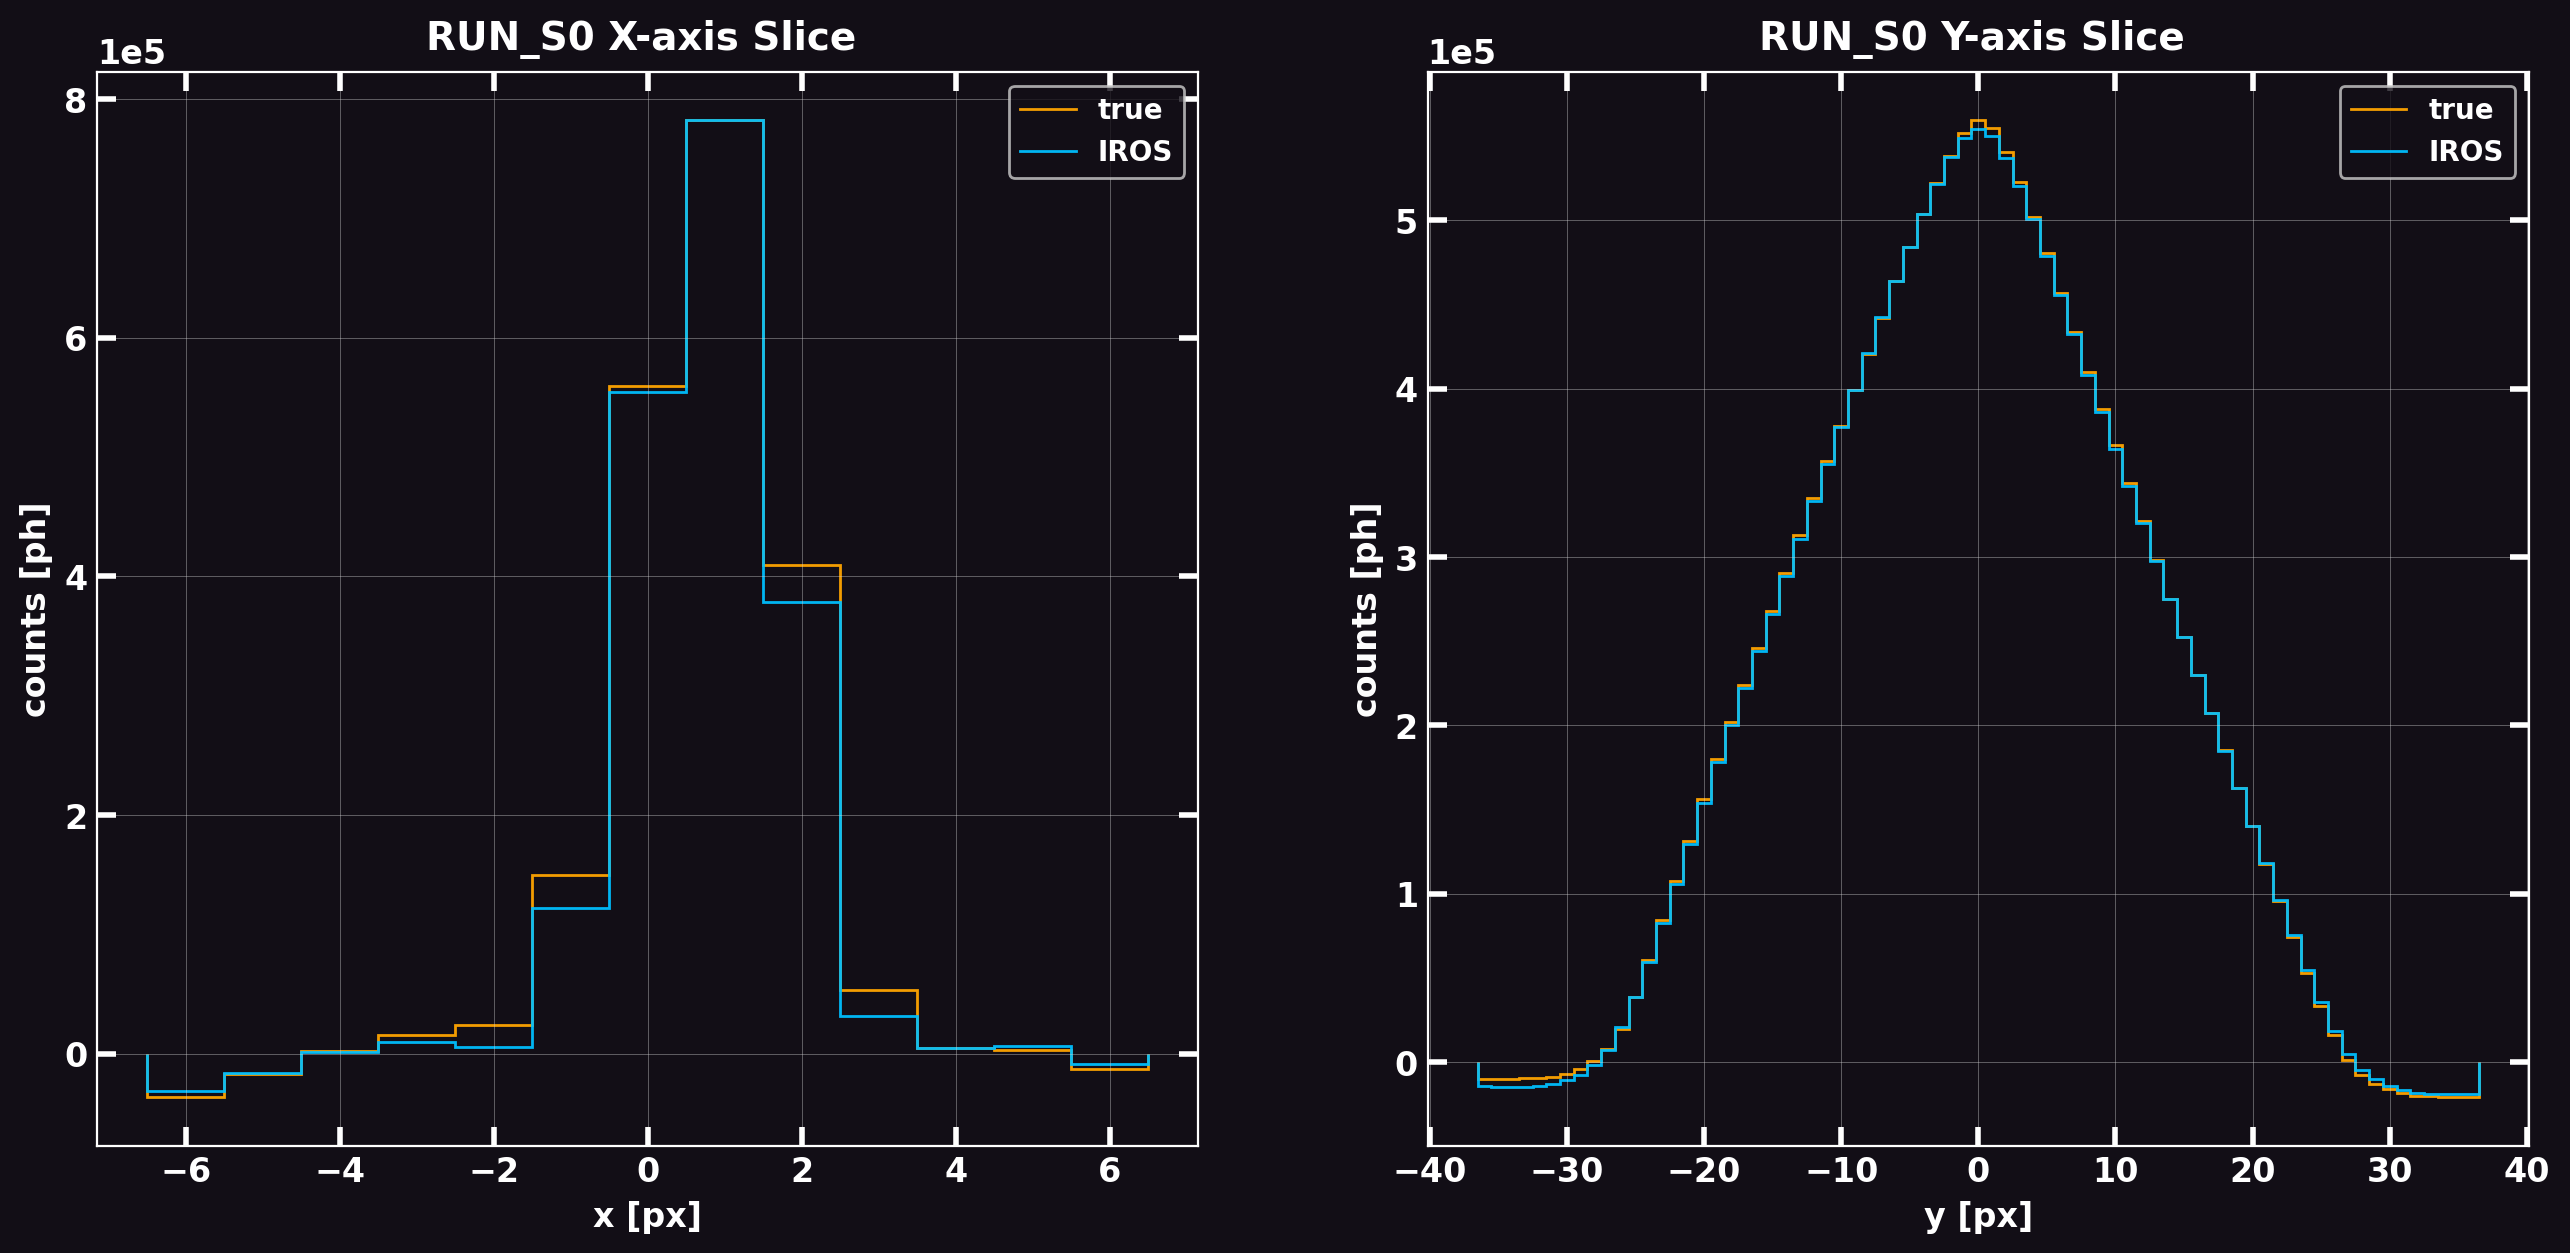

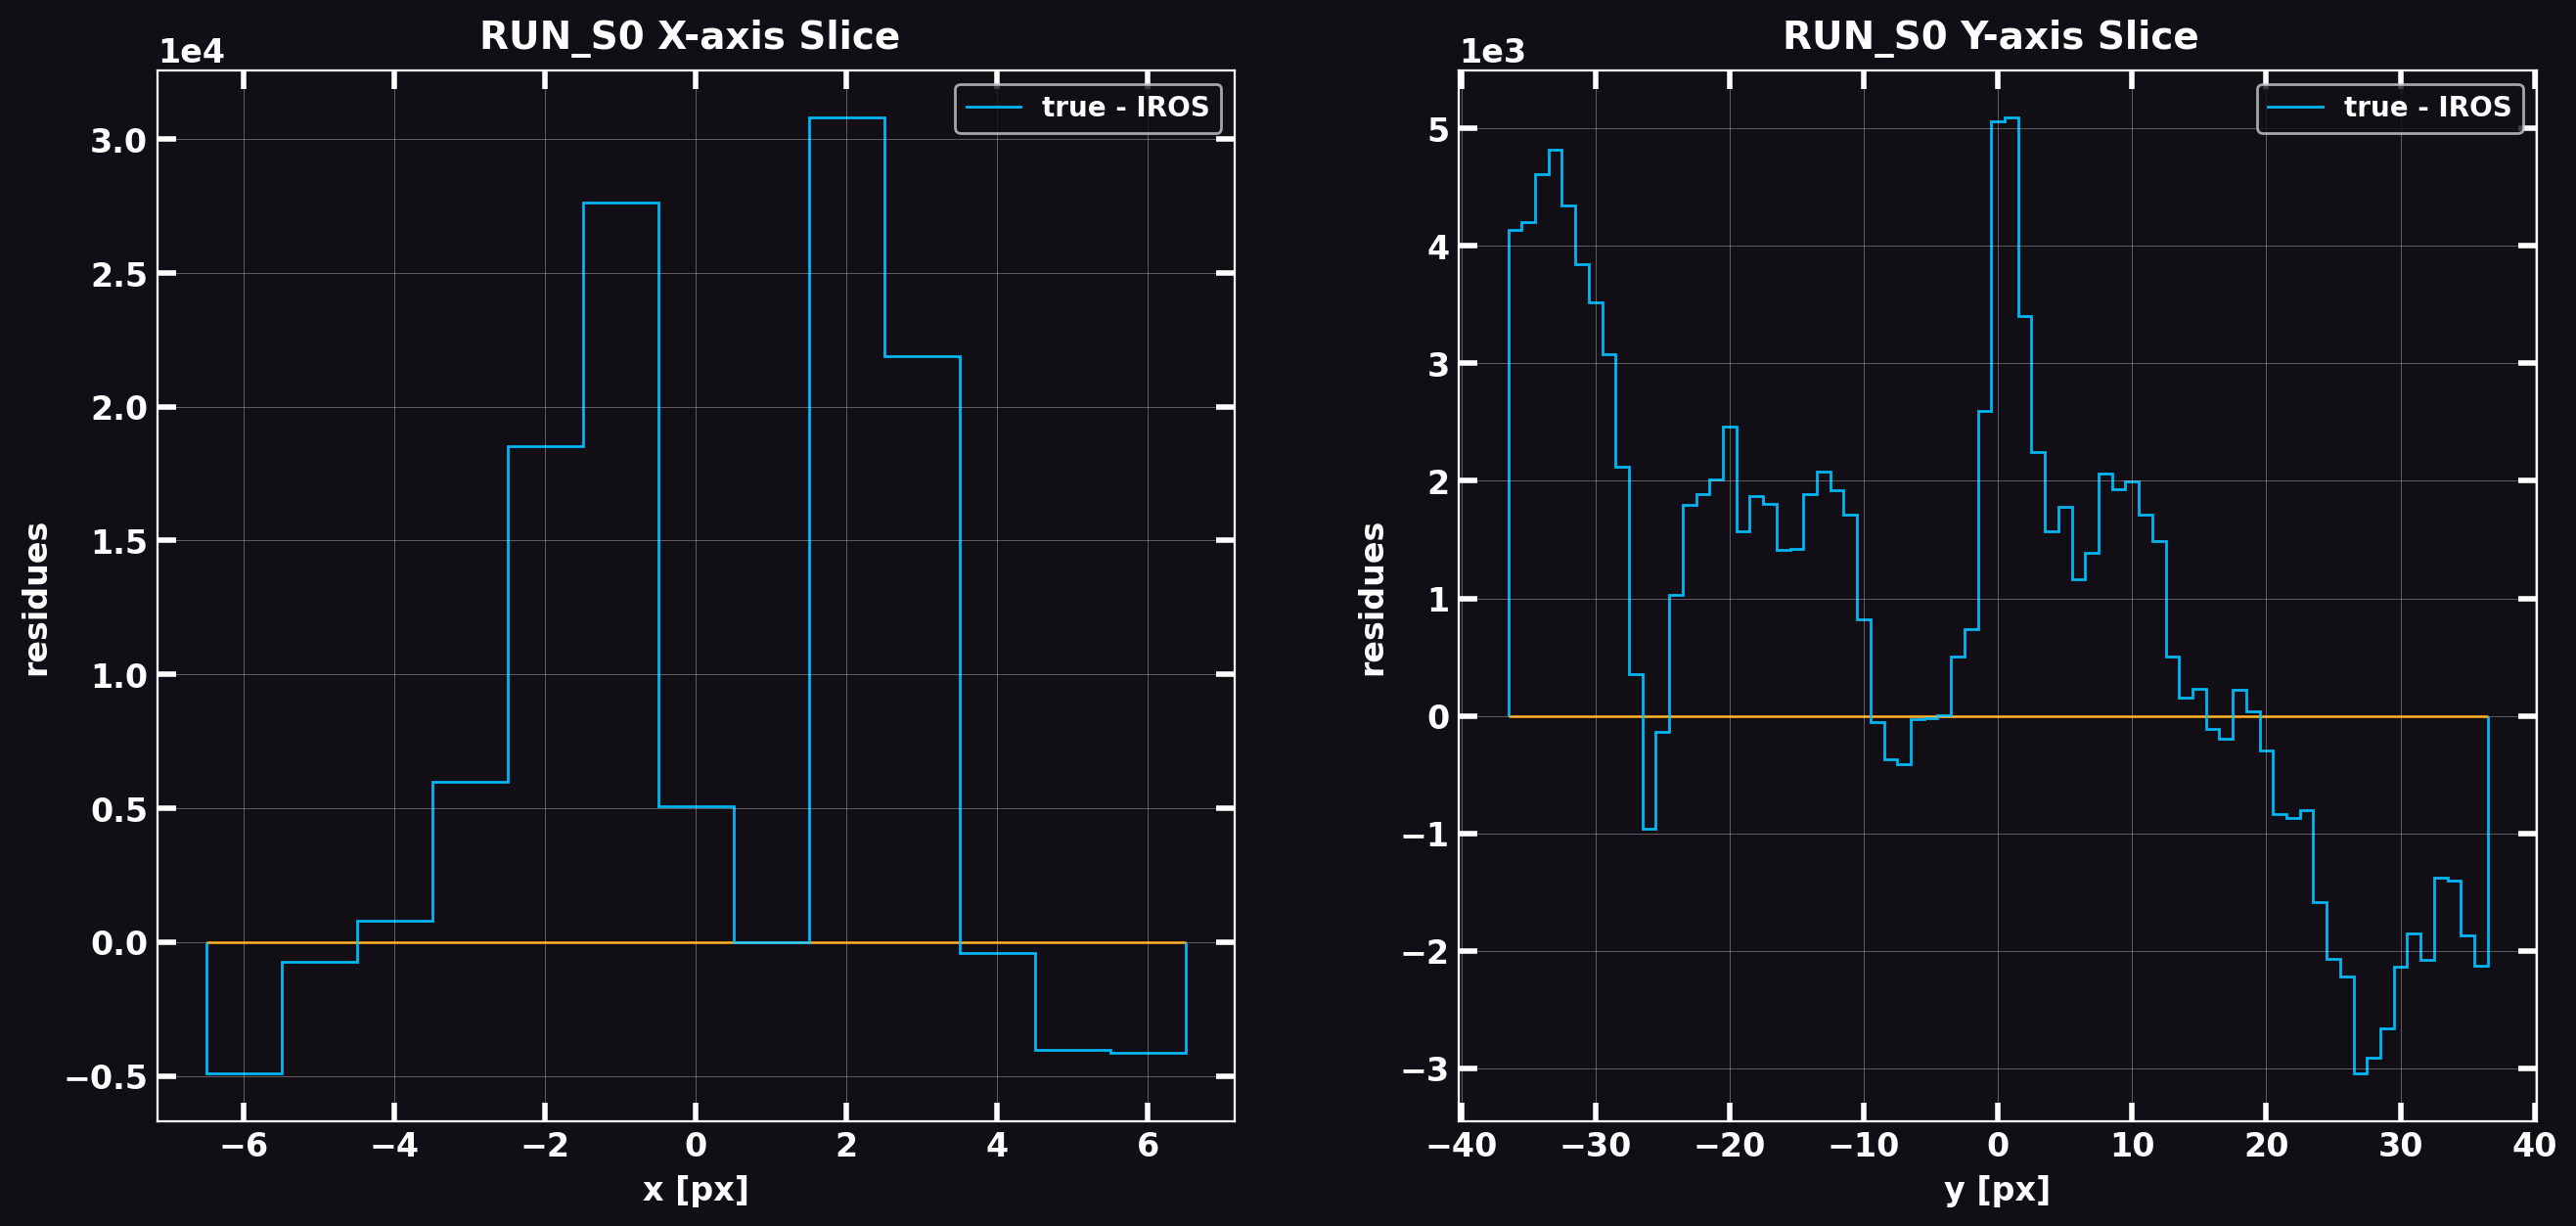

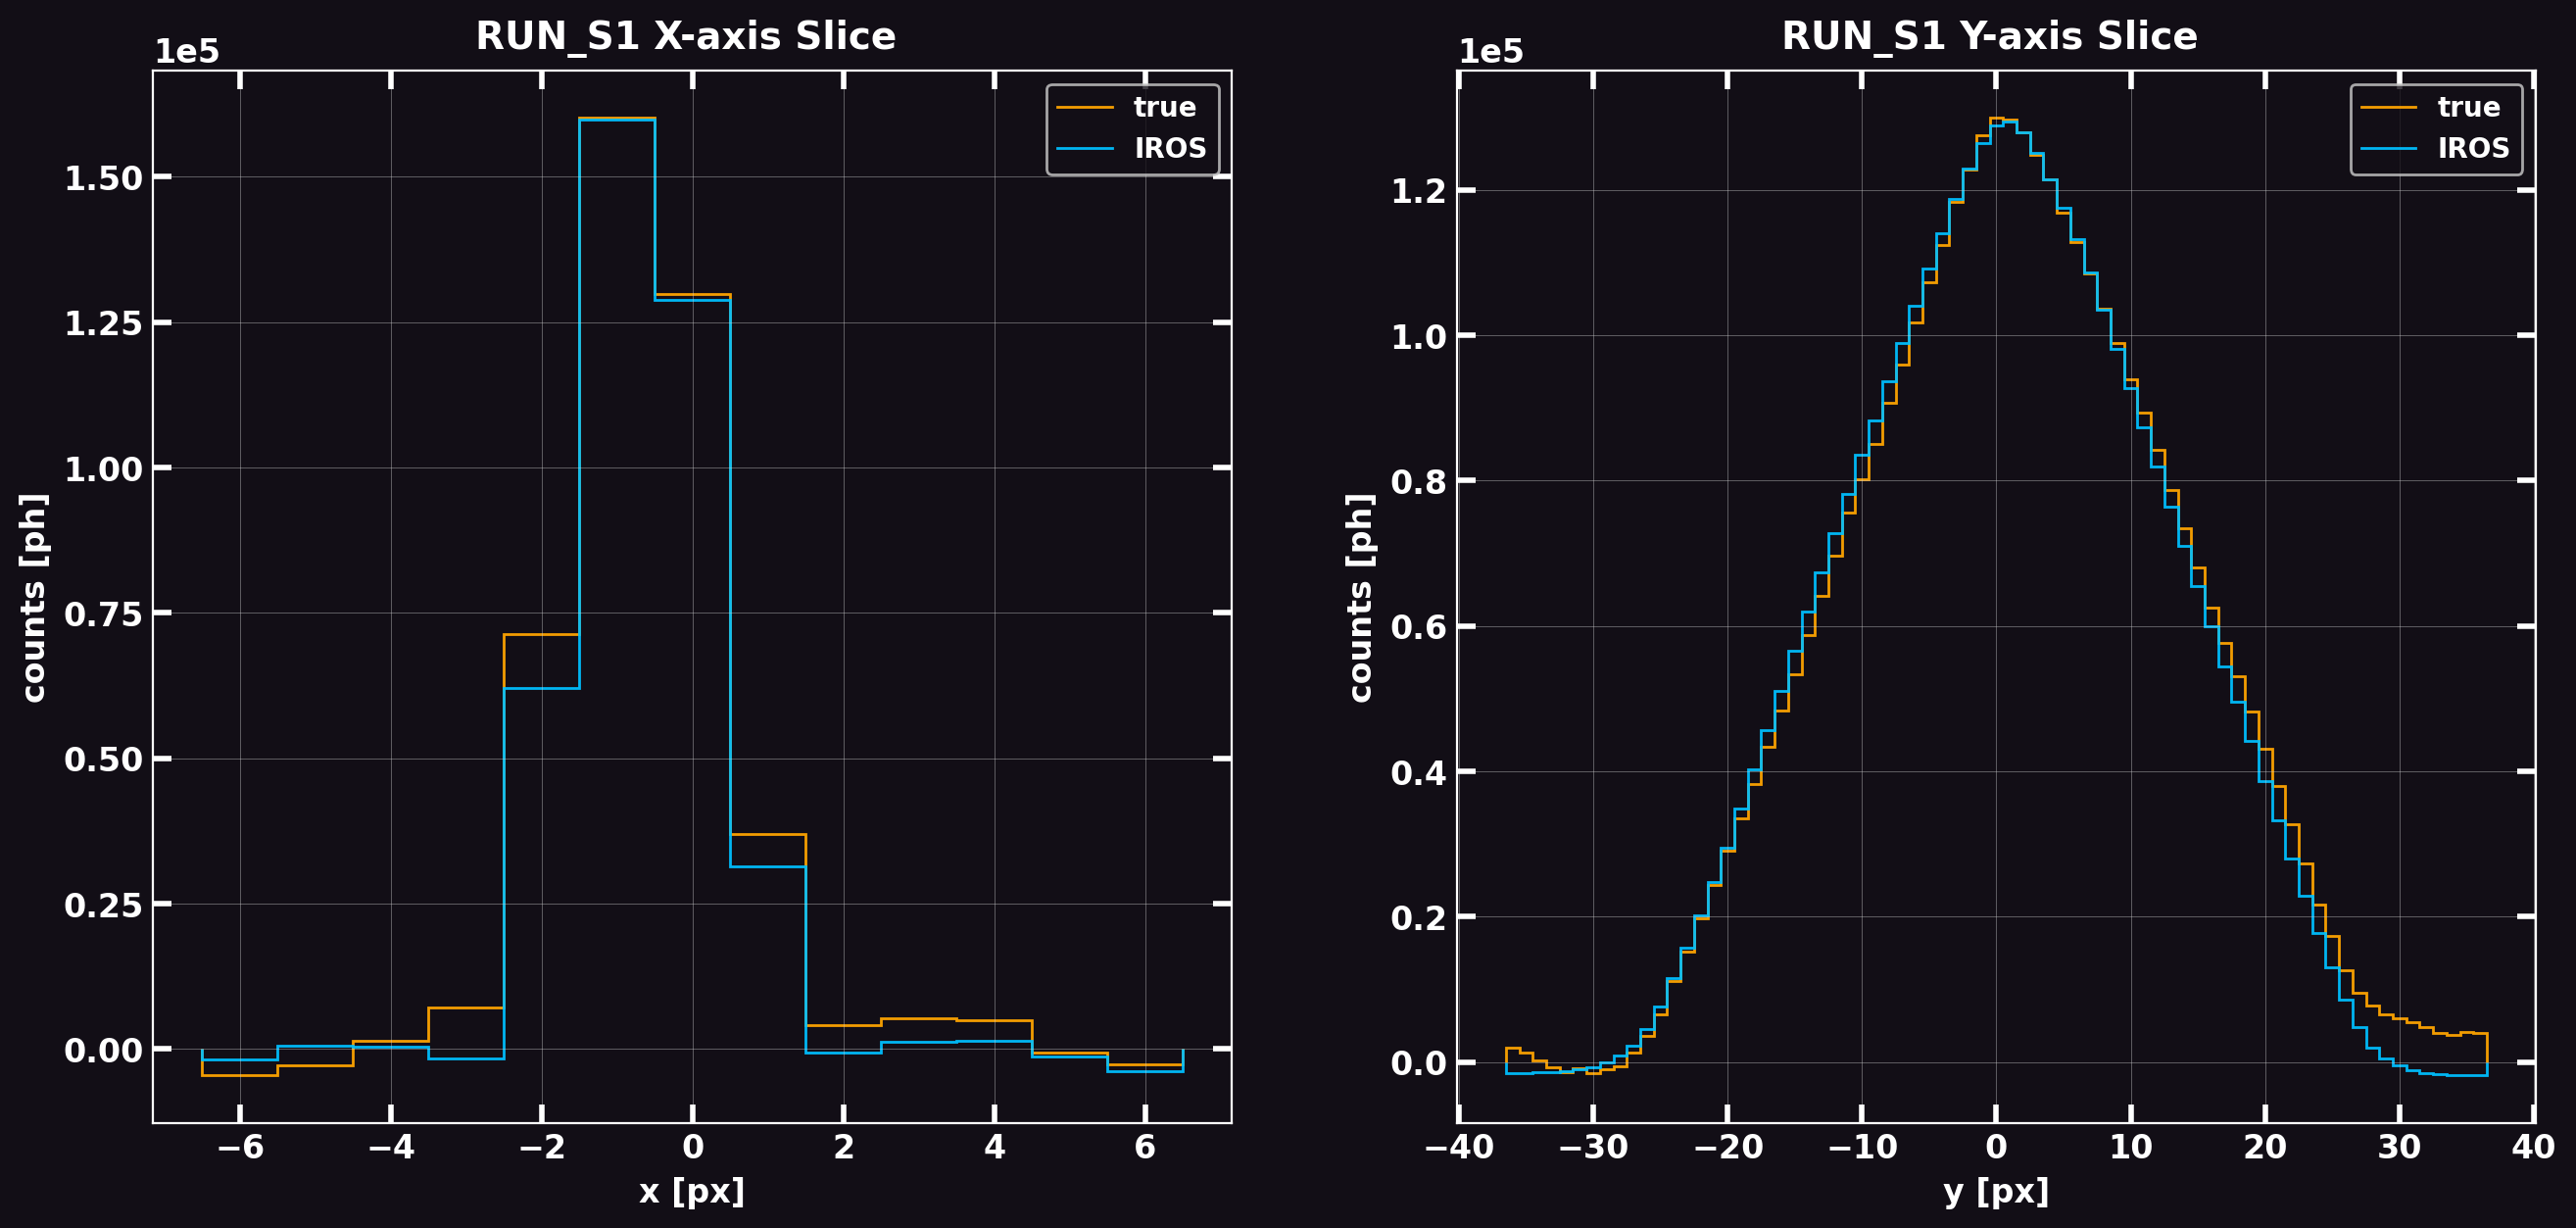

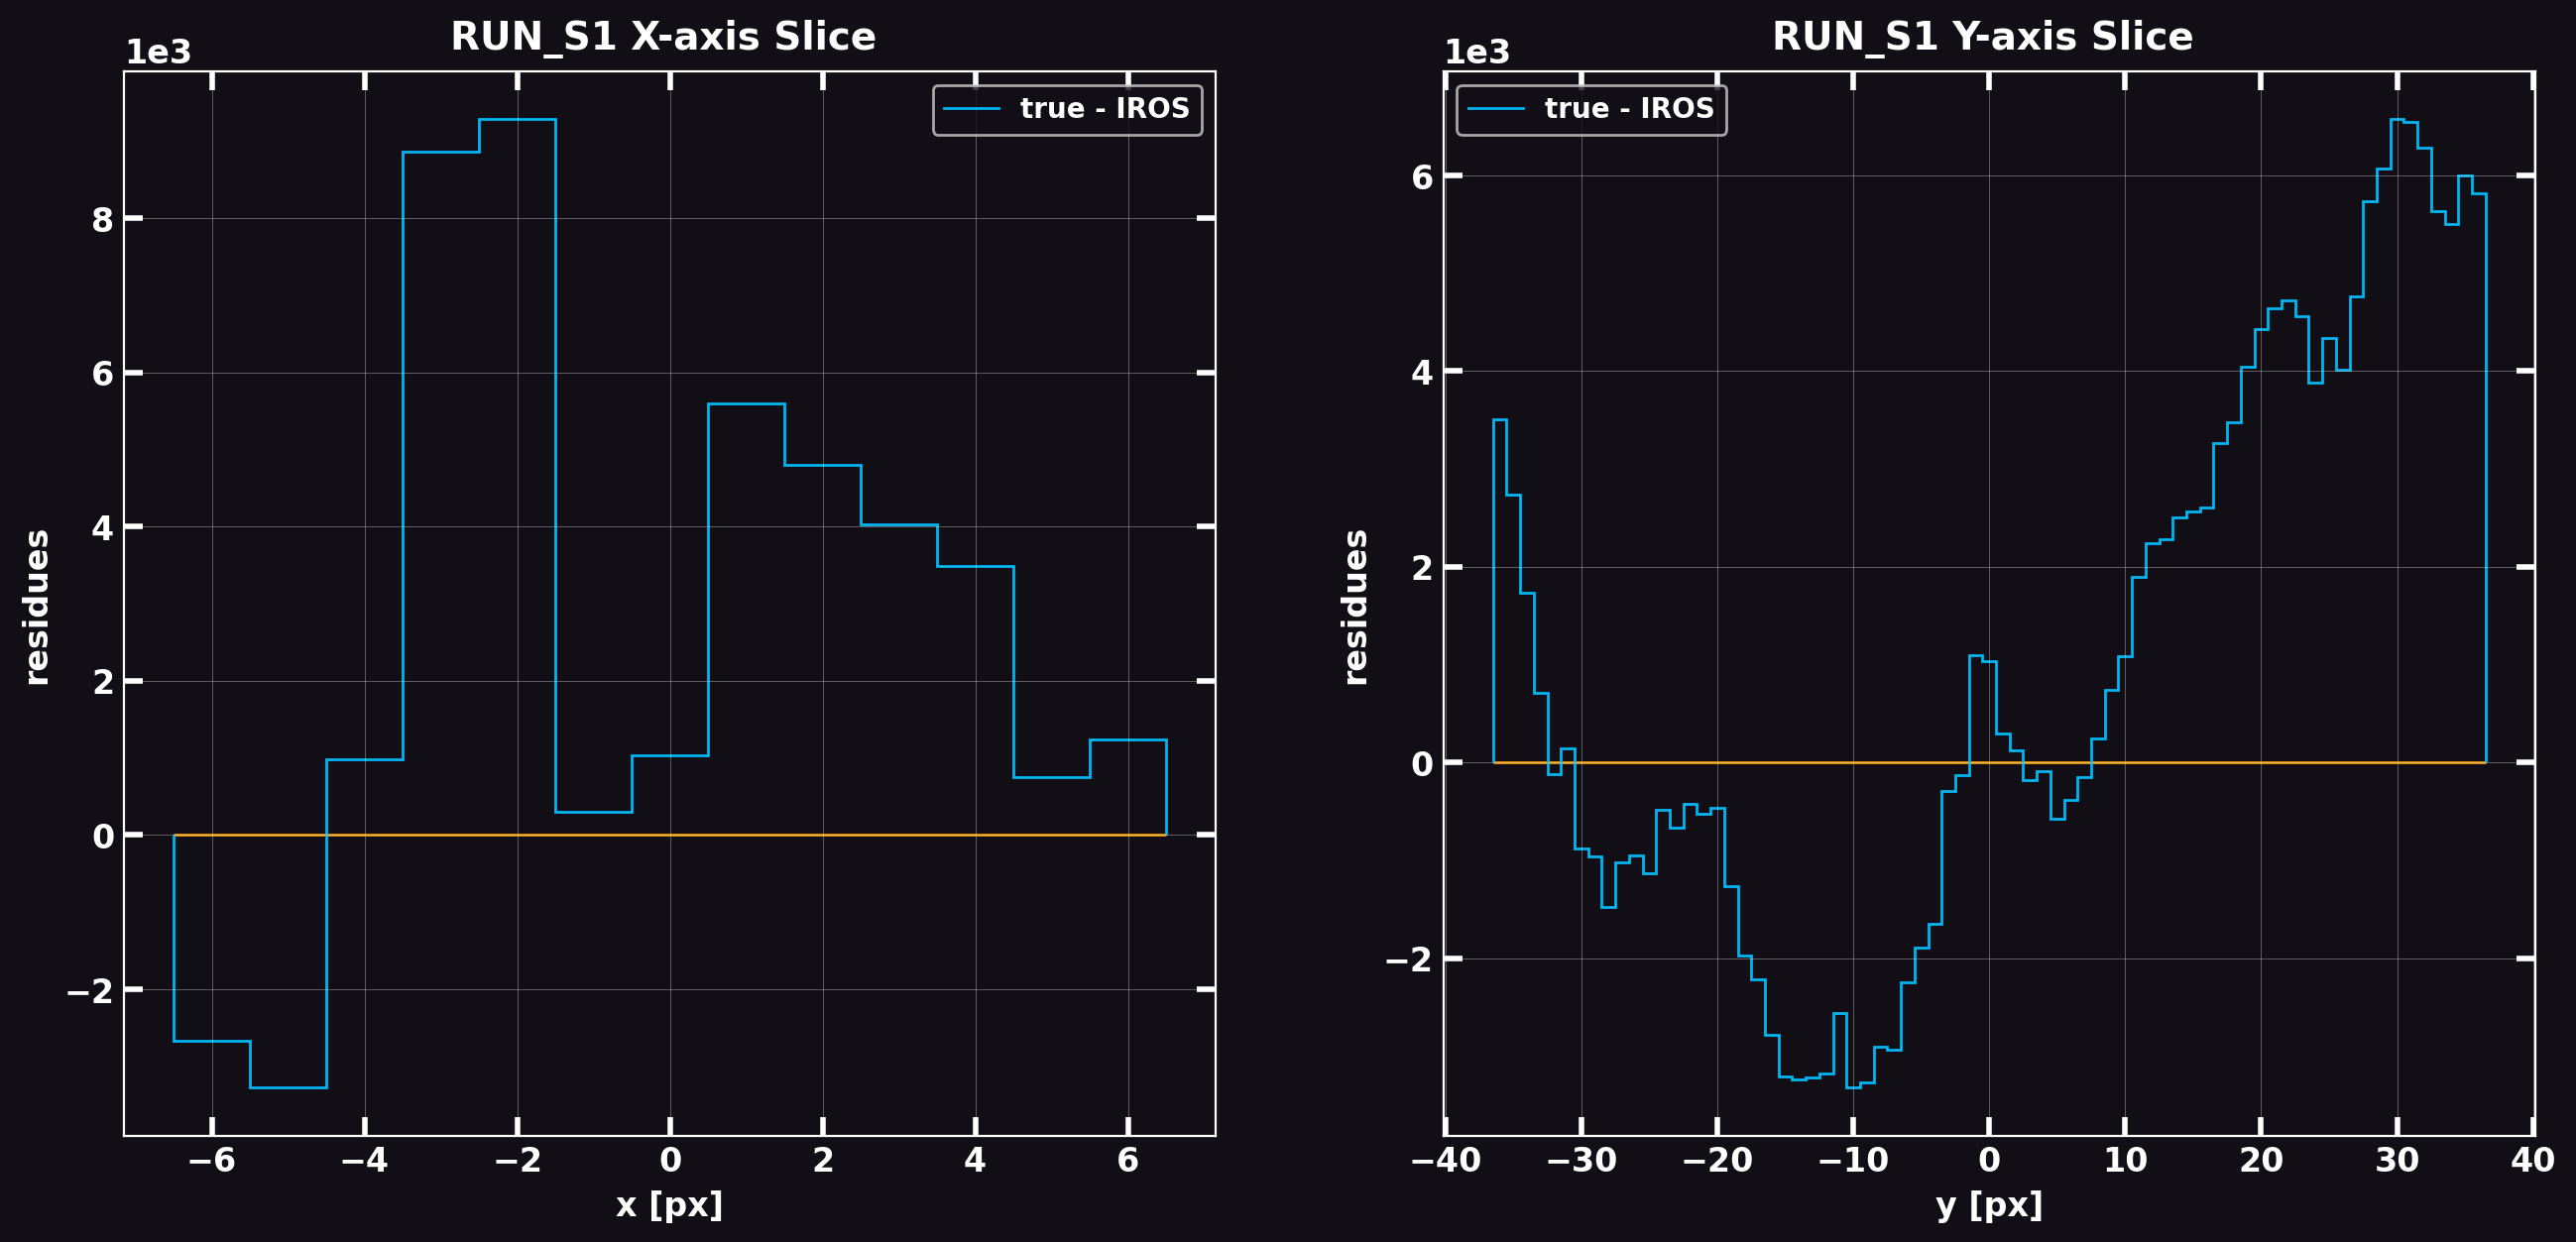

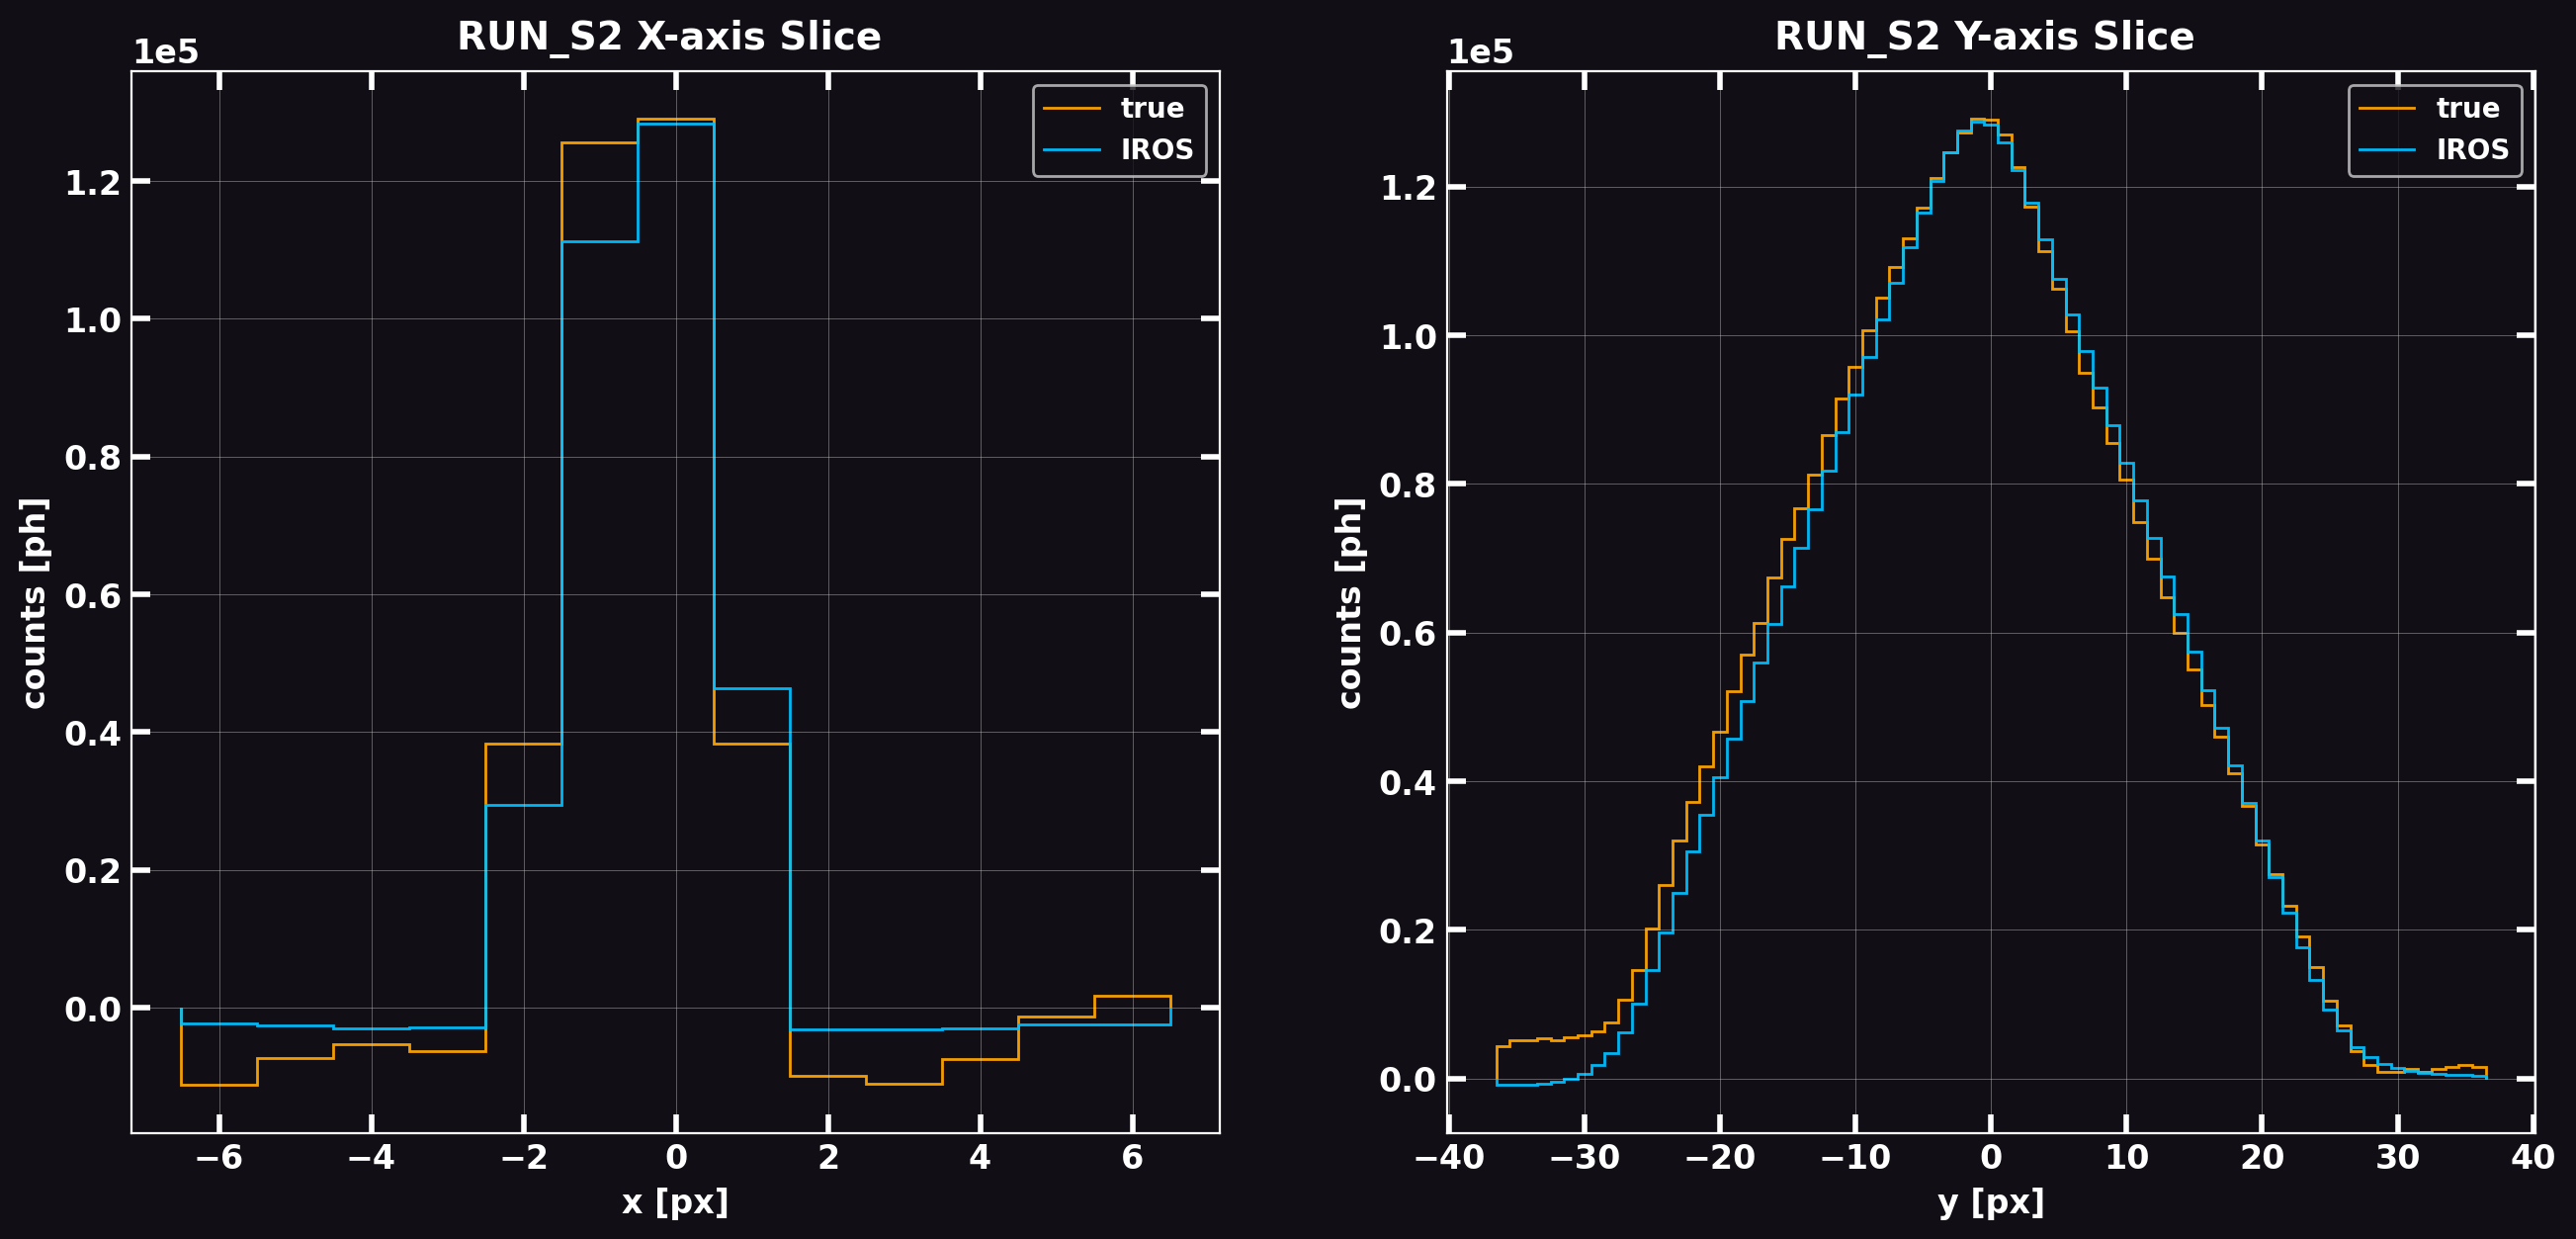

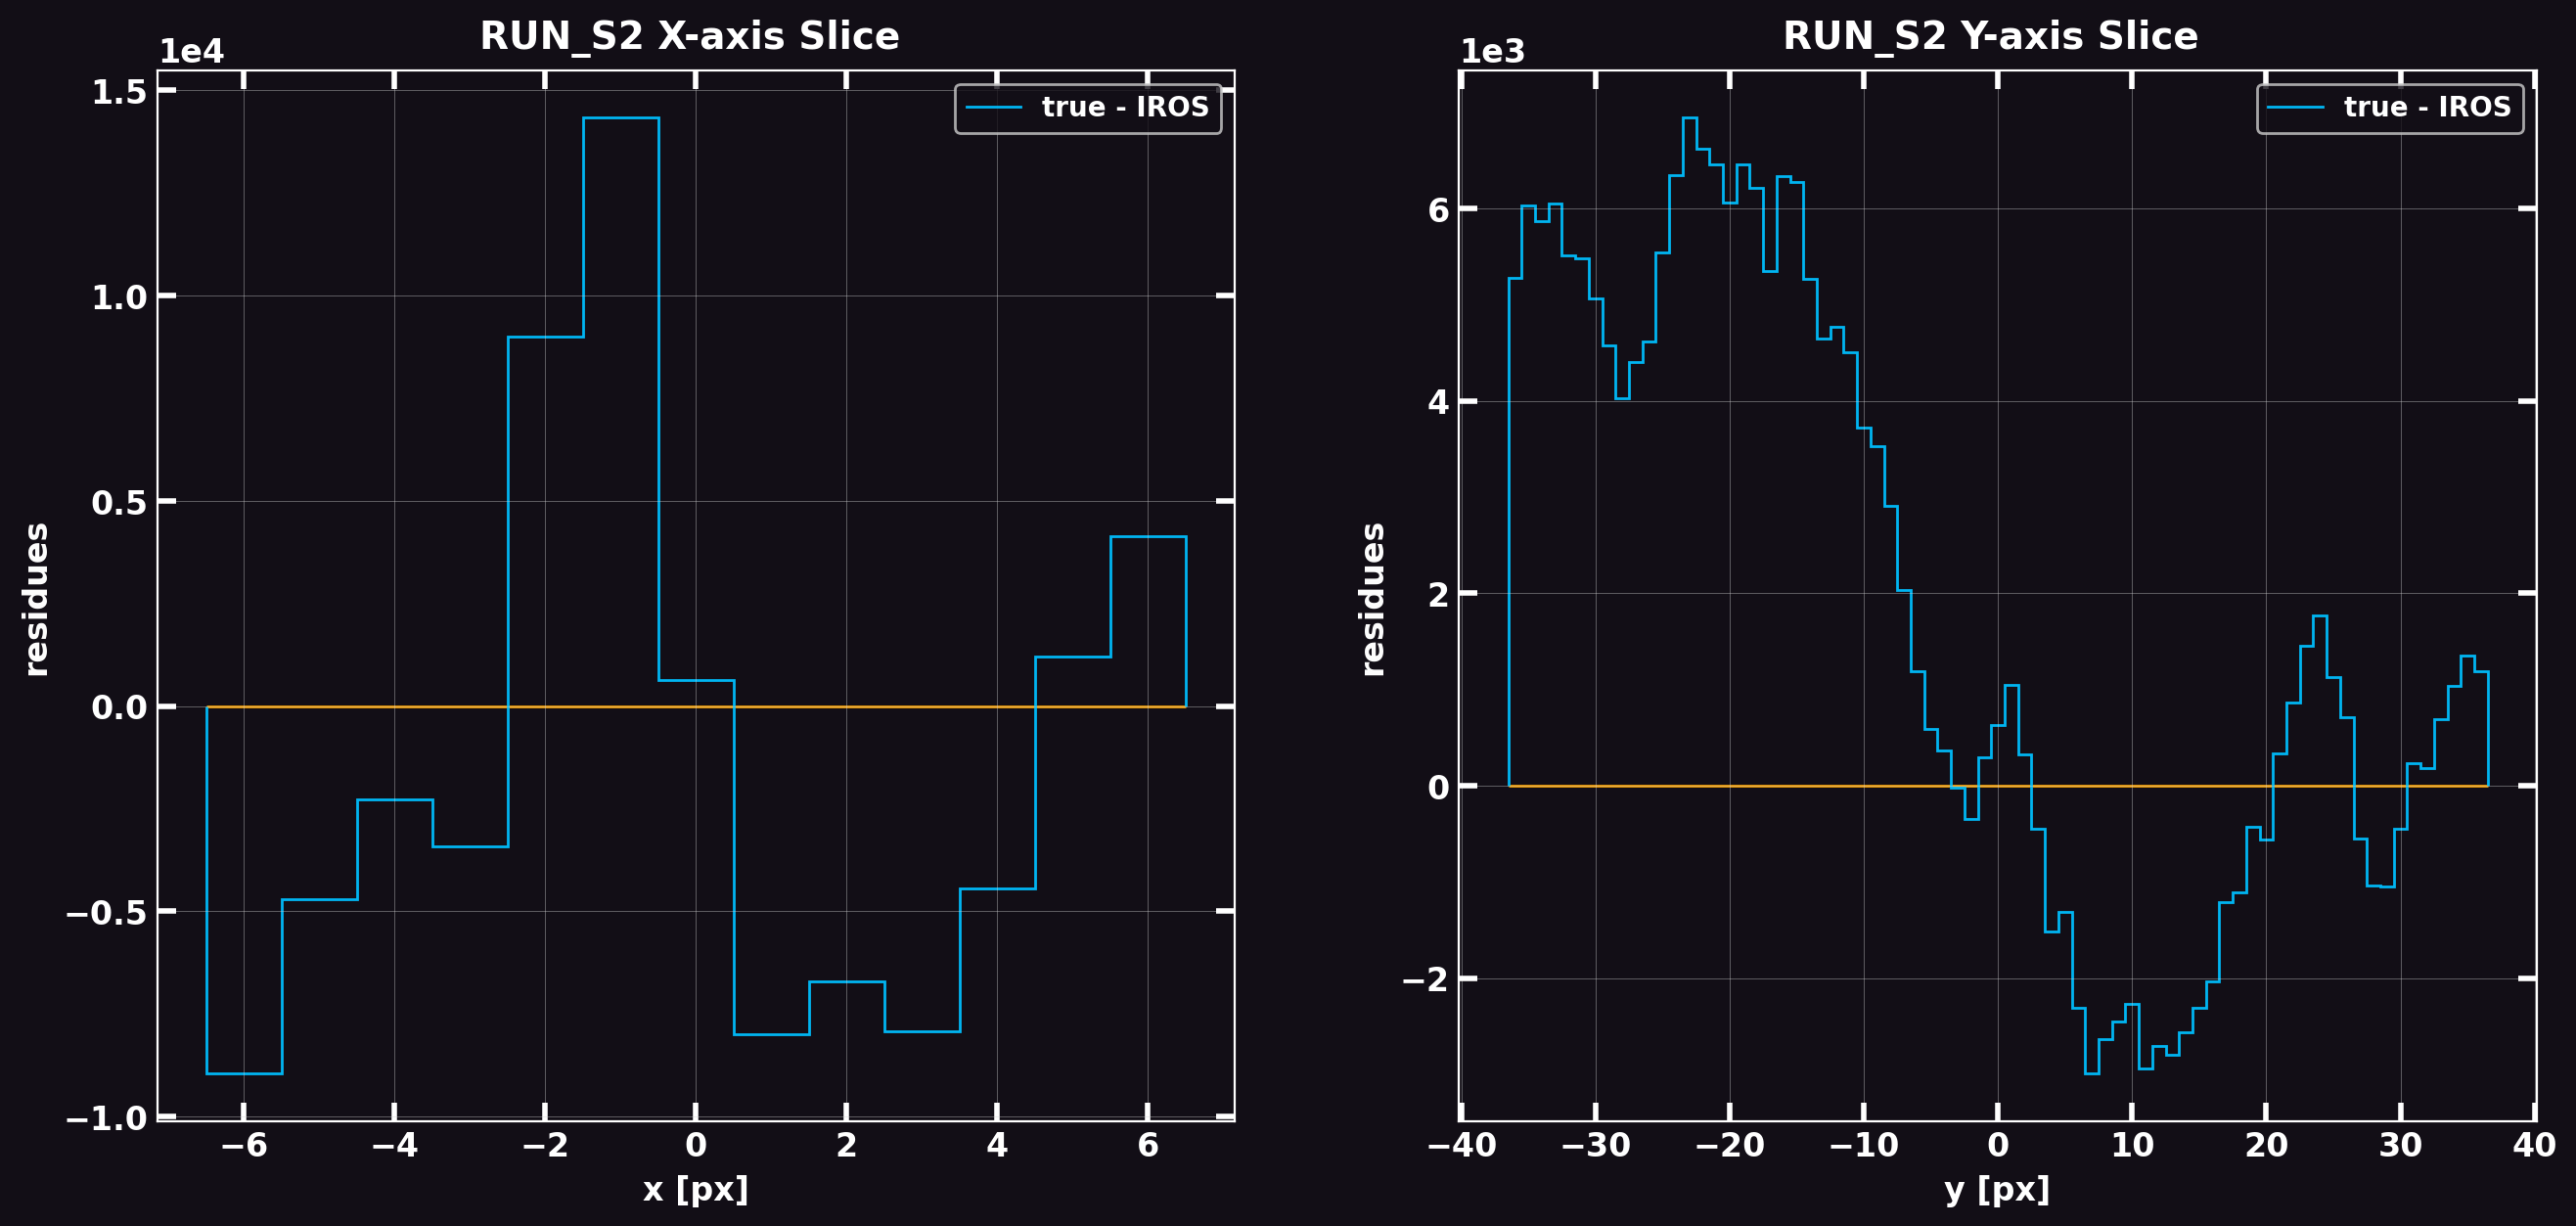

In [11]:
true_sky: NDArray = decode(wfm, detector)

save_to = None  #'/home/edoardo/Desktop/ebands_IROS_run'
plot_results(true_sky, candidates, wfm, save_to=save_to)